In [1]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False


In [2]:
import numpy as np

Dataset_Train['Segmentation_Combined'] = np.where(
    Dataset_Train['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Train['Segmentation']
)

Dataset_Test['Segmentation_Combined'] = np.where(
    Dataset_Test['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Test['Segmentation']
)
Dataset_Train.head()
Dataset_Test.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier,Segmentation_Combined
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False,D
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False,D
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False,ABC
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False,ABC
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False,ABC


In [3]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
#Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
#Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [4]:
print("Columns in Dataset_Train:", Dataset_Train.columns.tolist())
print("Columns in Dataset_Test:", Dataset_Test.columns.tolist())

Columns in Dataset_Train: ['Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1', 'Marital_Spending_Group', 'Segmentation_Combined']
Columns in Dataset_Test: ['Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1', 'Marital_Spending_Group', 'Segmentation_Combined']


In [5]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

🔹 Class Counts:
Segmentation_Combined
ABC    6119
D      2406
Name: count, dtype: int64

🔹 Class Percentages:
Segmentation_Combined
ABC    71.78
D      28.22
Name: proportion, dtype: float64


C:\Users\Ashani Madushani\AppData\Local\Temp\ipykernel_4296\3910772525.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')


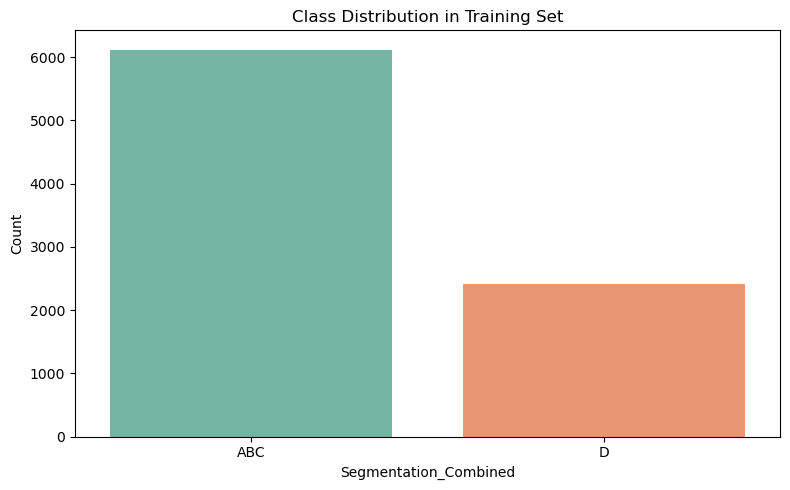

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of instances in each class
class_counts = Dataset_Train['Segmentation_Combined'].value_counts()
class_percentages = Dataset_Train['Segmentation_Combined'].value_counts(normalize=True) * 100

# Display results
print("🔹 Class Counts:")
print(class_counts)
print("\n🔹 Class Percentages:")
print(class_percentages.round(2))

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')
plt.title("Class Distribution in Training Set")
plt.xlabel("Segmentation_Combined")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


✅ Train Accuracy: 0.7924926686217009
✅ Test Accuracy: 0.7884615384615384

🔹 Classification Report (Train):
               precision    recall  f1-score   support

         ABC       0.82      0.92      0.86      6119
           D       0.69      0.47      0.56      2406

    accuracy                           0.79      8525
   macro avg       0.75      0.70      0.71      8525
weighted avg       0.78      0.79      0.78      8525


🔹 Classification Report (Test):
               precision    recall  f1-score   support

         ABC       0.81      0.92      0.86      1530
           D       0.69      0.46      0.55       602

    accuracy                           0.79      2132
   macro avg       0.75      0.69      0.71      2132
weighted avg       0.78      0.79      0.77      2132



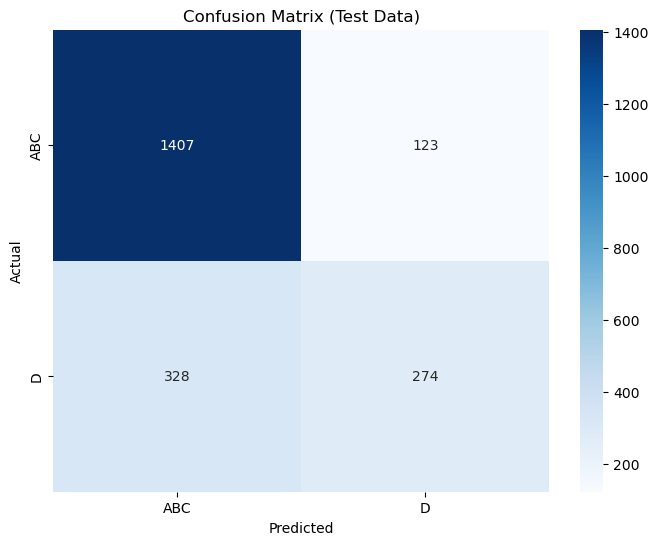

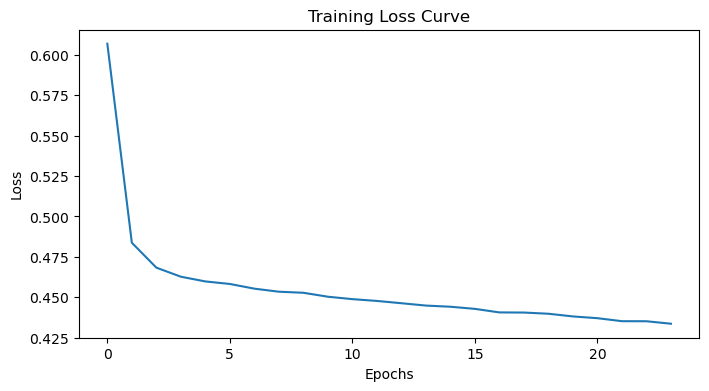

In [7]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Define features and target
X_train = Dataset_Train.drop(columns=['Segmentation_Combined'])
y_train = Dataset_Train['Segmentation_Combined']
X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']

# Identify column types
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize and train MLP
model = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
model.fit(X_train_processed, y_train_encoded)

# Predictions
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Convert encoded predictions back to original labels
y_train_pred_labels = le.inverse_transform(y_train_pred)
y_test_pred_labels = le.inverse_transform(y_test_pred)

# Evaluation
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred_labels))
print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred_labels))

print("\n🔹 Classification Report (Train):\n", classification_report(y_train, y_train_pred_labels))
print("\n🔹 Classification Report (Test):\n", classification_report(y_test, y_test_pred_labels))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Iteration 1, loss = 0.57939039
Validation score: 0.748366
Iteration 2, loss = 0.52512255
Validation score: 0.745915
Iteration 3, loss = 0.51794106
Validation score: 0.758170
Iteration 4, loss = 0.51417134
Validation score: 0.763072
Iteration 5, loss = 0.51049011
Validation score: 0.758987
Iteration 6, loss = 0.50574859
Validation score: 0.769608
Iteration 7, loss = 0.49903109
Validation score: 0.769608
Iteration 8, loss = 0.49622180
Validation score: 0.775327
Iteration 9, loss = 0.49207422
Validation score: 0.758170
Iteration 10, loss = 0.48715480
Validation score: 0.769608
Iteration 11, loss = 0.48166254
Validation score: 0.754902
Iteration 12, loss = 0.48486044
Validation score: 0.773693
Iteration 13, loss = 0.47369173
Validation score: 0.763072
Iteration 14, loss = 0.46881756
Validation score: 0.750817
Iteration 15, loss = 0.47078273
Validation score: 0.773693
Iteration 16, loss = 0.46218889
Validation score: 0.767974
Iteration 17, loss = 0.45840323
Validation score: 0.772059
Iterat

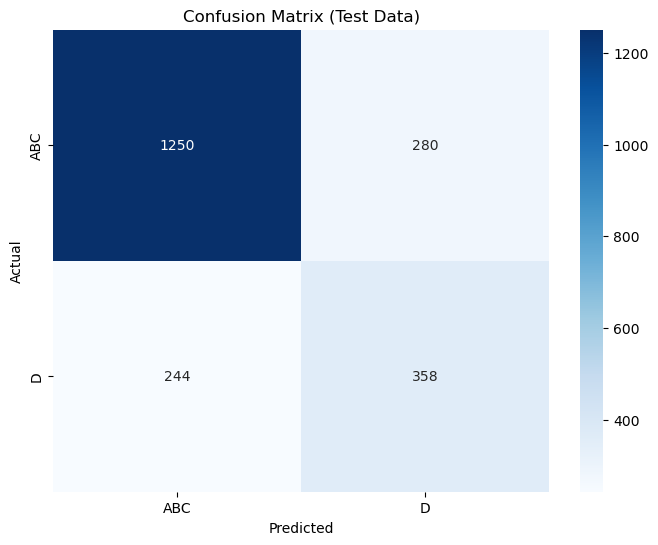

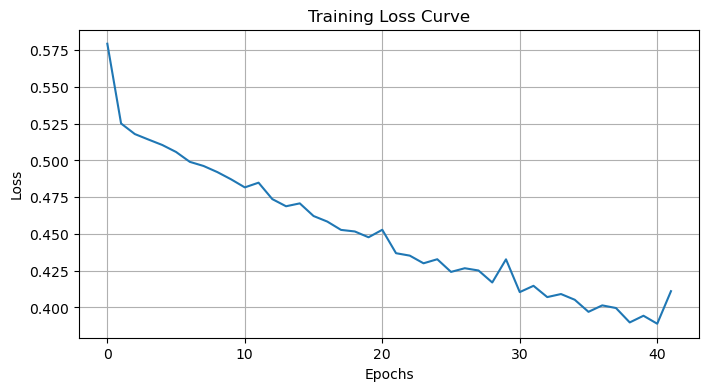


Class Distribution:
Original: [6119 2406]
After SMOTE: [6119 6119]


In [8]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


# Define features and target
X_train = Dataset_Train.drop(columns=['Segmentation_Combined'])
y_train = Dataset_Train['Segmentation_Combined']
X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']

# Preprocessing pipeline
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Address class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train_encoded)

# Optimized MLP model
model = MLPClassifier(
    hidden_layer_sizes=(150, 100, 50),  # Deeper architecture
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

# Train model
model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred = model.predict(X_train_processed)  # Original training data
y_test_pred = model.predict(X_test_processed)

# Decode predictions
y_train_pred_labels = le.inverse_transform(y_train_pred)
y_test_pred_labels = le.inverse_transform(y_test_pred)

# Evaluation
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred_labels))
print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred_labels))

print("\n🔹 Classification Report (Train):\n", classification_report(y_train, y_train_pred_labels))
print("\n🔹 Classification Report (Test):\n", classification_report(y_test, y_test_pred_labels))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Class distribution before/after SMOTE
print("\nClass Distribution:")
print("Original:", np.bincount(y_train_encoded))
print("After SMOTE:", np.bincount(y_train_resampled))